In [24]:
!pip install transformers -q
!pip install lovely-tensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lovely-tensors]


In [19]:
import torch
import inspect
import json
import types
import umap
import requests
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import lovely_tensors as lt
import numpy as np
import torch.nn.functional as F
from torch import Tensor
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image



In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Task 2.1: Using a Pre-trained ViT10 for Image Classification

### Image 1

In [8]:
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
# print(image.size)

model_src = 'google/vit-base-patch16-224'
processor = ViTImageProcessor.from_pretrained(model_src)
model = ViTForImageClassification.from_pretrained(model_src)

inputs = processor(images=image, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
idx = logits.argmax(-1).item()

print(model.config.id2label[idx])
# image.show()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Egyptian cat


### Image 2


In [13]:
url = 'https://images.unsplash.com/photo-1627896157734-4d7d4388f28b?ixid=M3w4MjcwNjd8MHwxfHNlYXJjaHwxfHxrMnxlbnwwfHx8fDE3ODY5OTk3NDN8MA&ixlib=rb-4.1.0&fit=max&q=80'

image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
# print(image.size)

inputs = processor(images=image, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
idx = logits.argmax(-1).item()

print(model.config.id2label[idx])

alp


### Image 3

In [11]:
url = 'https://images.unsplash.com/photo-1562426772-f7b1d159764b?ixid=M3w4MjcwNjd8MHwxfHNlYXJjaHwxfHxoaXBwb3xlbnwwfHx8fDE3ODY5OTk2MTZ8MA&ixlib=rb-4.1.0&fit=max&q=80'

image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
# print(image.size)

inputs = processor(images=image, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
idx = logits.argmax(-1).item()

print(model.config.id2label[idx])

hippopotamus, hippo, river horse, Hippopotamus amphibius


## Task 2.2. Visualizing Patch Attention:

In [44]:
model_src = 'google/vit-base-patch16-224'
processor = ViTImageProcessor.from_pretrained(model_src)
model = ViTForImageClassification.from_pretrained(model_src, output_attentions=True)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [70]:
url = "https://images.unsplash.com/photo-1552410260-0fd9b577afa6?ixid=M3w4MjcwNjd8MHwxfHNlYXJjaHw5fHxsaW9ufGVufDB8fHx8MTc4NzAxNDAzMnww&ixlib=rb-4.1.0&fit=max&q=80"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

inputs = processor(images=image, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model(**inputs)


In [71]:
logits = outputs.logits
idx = logits.argmax(-1).item()

print(model.config.id2label[idx])

lion, king of beasts, Panthera leo


In [72]:
print(outputs.attentions[-1].shape)

torch.Size([1, 12, 197, 197])


In [ ]:
last_layer = outputs.attentions[-1]
cls_attention = last_layer[:, :, 0, :]

print(cls_attention.shape)

patch_attention = cls_attention[:, :, 1:]

print(patch_attention.shape)



torch.Size([1, 12, 197])
torch.Size([1, 12, 196])
torch.Size([1, 196])
torch.Size([1, 14, 14])


In [76]:
for head_idx in range(12):
    head_map = cls_attention[0, head_idx, 1:].reshape(14,14)  # single head, unaveraged
    top_val = head_map.flatten().max().item()
    print(f"Head {head_idx}: max attention = {top_val:.4f}")

Head 0: max attention = 0.0347
Head 1: max attention = 0.0553
Head 2: max attention = 0.1195
Head 3: max attention = 0.1069
Head 4: max attention = 0.1155
Head 5: max attention = 0.0329
Head 6: max attention = 0.0893
Head 7: max attention = 0.1024
Head 8: max attention = 0.0544
Head 9: max attention = 0.0374
Head 10: max attention = 0.0642
Head 11: max attention = 0.0471


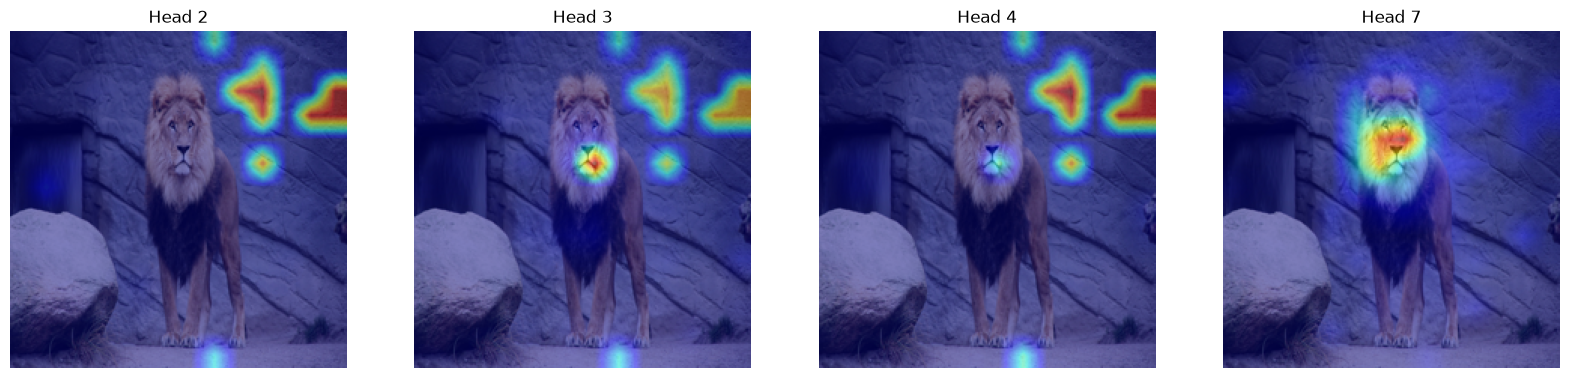

In [ ]:
top_heads = [2, 3, 4, 7]

fig, axes = plt.subplots(1, len(top_heads), figsize=(20, 5))

for i, head_idx in enumerate(top_heads):
    head_map = cls_attention[0, head_idx, 1:].reshape(14, 14)  # (14,14)

    head_map_upsampled = F.interpolate(
        head_map.unsqueeze(0).unsqueeze(0),  # -> (1,1,14,14)
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    ).squeeze().detach().numpy()

    attn_norm = (head_map_upsampled - head_map_upsampled.min()) / \
                (head_map_upsampled.max() - head_map_upsampled.min())

    axes[i].imshow(image.resize((224,224)))
    axes[i].imshow(attn_norm, cmap='jet', alpha=0.5)
    axes[i].set_title(f"Head {head_idx}")
    axes[i].axis('off')

plt.savefig("per_head_attention.png", bbox_inches='tight')
plt.show()

In [ ]:
patch_attention = patch_attention.mean(dim=1)

print(patch_attention.shape)

attention_map = patch_attention.reshape(-1, 14, 14)

print(attention_map.shape)

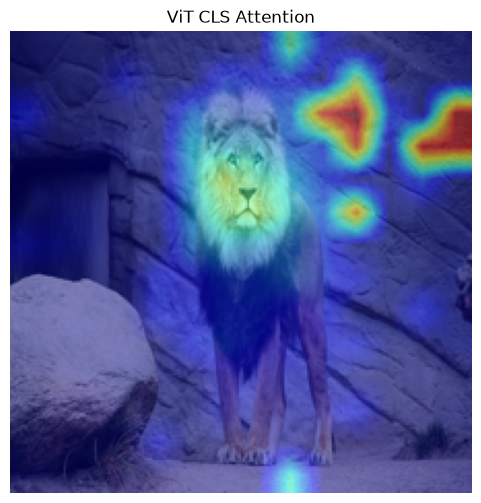

In [74]:
attention_map_upsampled = F.interpolate(
    attention_map.unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

attention_map_upsampled = attention_map_upsampled.squeeze().detach().numpy()

attn_norm = (attention_map_upsampled - attention_map_upsampled.min()) / \
            (attention_map_upsampled.max() - attention_map_upsampled.min())

# 3. Overlay on the original image
plt.figure(figsize=(6,6))
plt.imshow(image.resize((224,224)))       
plt.imshow(attn_norm, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("ViT CLS Attention")
plt.savefig("attention_overlay.png", bbox_inches='tight')
plt.show()